In [2]:
'''
this is a notebook that takes all the subjects' optimisation results, finetunes the best seed and outputs the results,
 including saving finetuned models 
'''
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from optimise_clnn import load_subject_data
from memory_upd_utils import polarity, extract_mem_updates
from model_utils import eval_ys, remove_gen, nans2none, force_model_params, fwd_pass
from models import LegacyElboGenerativeModelTop,ElboGenerativeModelTop, ElboGenerativeModelDualRate
from types import SimpleNamespace
import copy
from optimise_clnn import load_subject_data, eval_paradigms
import pickle
from memory_upd_utils import extract_adaptation_measurements
result_root = '/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/results/'
run_name = 'realthing403aaa_seedsJSwp4noTie'
coin_bics_path = '/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/coin_bics1000.txt'
paradigm_ = {k: 'evoked' if k <= 8 else 'spontaneous' for k in range(1,17)}
coin_bics = np.loadtxt(coin_bics_path)
experimental_data = {}
loss_traces= {}
output_traces= {}
prior_out_batch = {}
posterior_out_batch = {}
'''load model'''

import copy


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
args = SimpleNamespace(model='default',
                       enable_q_scale_tuning=False,
                       assume_opt_output_noise=True, 
                       enable_qlpf=False,
                       enable_ylpf=False,
                       enable_elpf=False,
                       noise_injection_node='a',
                       model_tie_lr_weight_decay=False,
                       bs=24,
                       zzz_legacy_init=False,
                       enable_output_scale_tuning=True,
                       enable_u_feedback_scale_tuning=False,
                       enable_direct_injection = False,
                       n=128)

model   =  ElboGenerativeModelTop(device=device, args=args)
records = {'best_rms':[], 'finetuned_rms':[], 'n':[]}
for k in range(1,17):
    experimental_data = load_subject_data(f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_{paradigm_[k]}_recovery_participant{(k-1)%8+1}.csv')

    ys = experimental_data[1] 
    ys = torch.tensor(ys, device=next(model.parameters()).device)
    a_exp = experimental_data[0]
    a_model = {}
    rms_list = []

    for seed in range(1,6):
        print(f'Loading seed {seed}')
        param_dict = torch.load(f'/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/results/{run_name}/run{k}_seed{seed}/params.pt', map_location=device)
        model.get_biases_and_w_in(128,device=device)
        model.load_state_dict(remove_gen(param_dict))
        force_model_params(model, {'sigma_x': 1e-7})
        a_model_ = eval_ys(model, ys, args)
        a_model[seed] = a_model_.mean(axis=1)
        rms = np.nanmean((a_model[seed]-a_exp)**2)**0.5
        print(rms)
        rms_list.append(rms)

    best_rms = np.min(rms_list)
    best_seed = np.argmin(rms_list)+1
    param_dict = torch.load(f'/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/results/{run_name}/run{k}_seed{best_seed}/params.pt', map_location=device)
    model.get_biases_and_w_in(128,device=device)
    model.load_state_dict(remove_gen(param_dict))
    force_model_params(model, {'sigma_x': 1e-7})

    a_model_ = eval_ys(model, ys, args)
    a_model['manual'] = a_model_.mean(axis=1)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    a_exp_torch = torch.tensor(a_exp, device=device)
    non_nan_mask = ~torch.isnan(a_exp_torch)
    a_exp_torch = a_exp_torch[non_nan_mask]
    n_epochs = 200
    for epoch in range(n_epochs):
        model.train()
        opt.zero_grad()
        a_model_mean = fwd_pass(model, ys, args, do_noise=False)
        a_model_mean = a_model_mean[non_nan_mask]
        loss = torch.mean((a_model_mean - a_exp_torch)**2)
        print(f'Epoch {epoch} Loss: {loss.item()}, RMSE: {loss.item()**0.5}')
        loss.backward()
        opt.step()
    #save finetuned model
    torch.save(model.state_dict(), f'/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/results/{run_name}/run{k}_seed{best_seed}/finetuned_params.pt')
    a_model_ = eval_ys(model, ys, args)
    a_model['finetuned'] = a_model_.mean(axis=1)
    finetuned_rms = np.nanmean((a_model['finetuned']-a_exp)**2)**0.5
    n = np.sum(~np.isnan(a_exp))
    records['best_rms'].append(best_rms)
    records['finetuned_rms'].append(finetuned_rms)
    records['n'].append(n)
from stat_utils import bic_gaussian_from_rmse
records['best_bics'] = []
records['finetuned_bics'] = []

In [ ]:
from stat_utils import bic_gaussian_from_rmse
records['best_bics'] = []
records['finetuned_bics'] = []
n_params = 5  # number of parameters in the model

for rms_best,rms_finetuned,n in zip(records['best_rms'], records['finetuned_rms'], records['n']):
    records['best_bics'].append(bic_gaussian_from_rmse(rms_best, n=n, k=n_params))
    records['finetuned_bics'].append(bic_gaussian_from_rmse(rms_finetuned, n=n, k=n_params))
records['finetuned_bics']
np.array(records['finetuned_bics']) - np.array(records['best_bics'])


array([-14.69280788,  -0.88601696,  -9.29554062, -22.57378369,
        -4.57398396,  -1.05232545, -19.87989874,  -9.61927816,
        -2.43407151,  -6.52824838,  -5.80635332, -25.94647895,
       -57.17698671,  -2.83465215,  -5.99661968,  -1.30817151])

([<matplotlib.axis.XTick at 0x7397f4e9c1c0>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16')])

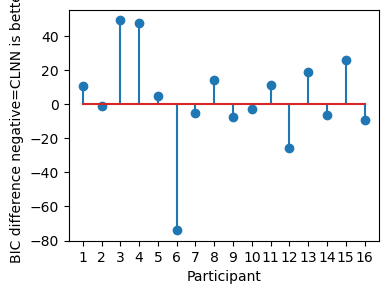

In [40]:
plt.figure(figsize=(4,3))
plt.stem(np.arange(1,len(coin_bics)+1), np.array(records['finetuned_bics']) - coin_bics)
plt.xlabel('Participant')
plt.ylabel('BIC difference negative=CLNN is better')
plt.xticks(np.arange(1,len(coin_bics)+1))